In [ ]:
!pip install quantecon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.7/322.7 kB 5.2 MB/s eta 0:00:00


# Import Packages

In [5]:
## usual impport functions : general use
import numpy as np
from numpy import cosh, zeros_like, mgrid, zeros
import matplotlib.pyplot as plt
import pandas as pd
import math

# from interpolation.complete_poly import (CompletePolynomial,
#                                          n_complete, complete_polynomial,
#                                          complete_polynomial_der,
#                                          _complete_poly_impl,
#                                          _complete_poly_impl_vec,
#                                          _complete_poly_der_impl,
#                                          _complete_poly_der_impl_vec)
from numba import jit, vectorize, njit, prange

## scipy functions for optimization (not all used)
import scipy.optimize as opt
from scipy.optimize import root
from scipy.sparse import spdiags, kron
from scipy.sparse.linalg import spilu, LinearOperator, eigs
from scipy.optimize import leastsq
from scipy.optimize import minimize
from scipy.special import j1
from scipy.sparse import lil_matrix
from scipy.interpolate import interp1d ## 1d interpolation, 2d and radial basis are avaiable for higher dimension interpolation
from typing import NamedTuple, Callable
from collections import namedtuple
from scipy.special import roots_hermite
from scipy.interpolate import RegularGridInterpolator

from concurrent.futures import ProcessPoolExecutor
from multiprocessing import Pool
import requests
import time
from time import time

from dataclasses import dataclass
from numpy.linalg import eig

import os
print(f"Available CPUs: {os.cpu_count()}")
### quantecon functions
# import quantecon as qe
# import quantecon_wasm as qe_w
# from quantecon import compute_fixed_point
# from quantecon.markov import DiscreteDP

Available CPUs: 2


# Functions

In [13]:
## rouwenhorst method

## AR process - yt = (1- rho)*y_bar + rho*yt + et, sigma_e

def rouwenhorst_matrix(params):
  p = (1+params.rho)/2
  q = p

  mat_temp=np.array([[p,1-p],[1-q,q]])
  sigma_y = params.sigma / np.sqrt(1 - params.rho**2)
  delta = sigma_y*np.sqrt(params.nbn-1)

  for i in range(params.nbn-2):
    a = mat_temp.shape[0]
    mat_temp_next = np.zeros((a+1,a+1))
    mat_temp_next[:a,:a] += p*mat_temp
    mat_temp_next[:a,1:] += (1-p)*mat_temp
    mat_temp_next[1:,:a] += (1-p)*mat_temp
    mat_temp_next[1:,1:] += p*mat_temp
    mat_temp = mat_temp_next
    mat_temp[1:a,:] = mat_temp[1:a,:]/2

  return mat_temp, delta


def stationary_distribution(Pi):

  vals, vecs = np.linalg.eig(Pi)
  index = np.argmin(np.abs(vals - 1.0))
  pi = vecs[:, index].real
  pi = pi / np.sum(pi)

  return pi


def stationary_distribution_stable(Pi,max_iter=100,tol = 1e-07):
  N = Pi.shape[0]
  pi = np.ones(N) / N  # start uniform
  for _ in range(max_iter):
    pi_new = pi @ Pi
    if np.max(np.abs(pi_new - pi)) < tol:
        return pi_new
    pi = pi_new

  return pi


def discretize_state(params):

  p = (1+params.rho)/2
  Pi , delta = rouwenhorst_matrix(params)         ## discretize a log normal AR process so exp
  z = np.exp(np.linspace(-delta, delta, params.nbn))
  pi = stationary_distribution_stable(Pi)

  return Pi, pi, z

## functions


def f(params,k,z):
  return z*k**(params.alpha)


def fprime(params,k,z):
  return z*params.alpha*k**(params.alpha-1)


def u_c(params,c):
  if params.gamma == 1:
    return np.log(c)
  else:
    return c**(params.gamma-1)/(params.gamma-1)


def mu_c(params,c):
  return c**(-params.gamma)


def mu_c_inv(params,y):
  return y** (-1/params.gamma)


def chebyshev_grid(k_min, k_max, N):
    x = chebyshev_nodes(N)              # in [-1,1]
    return 0.5*(k_max - k_min)*(x + 1) + k_min


def cheby_pol(kz, order): ## chebyshev polynomial - usual
  N = len(kz)                     ## Chebypol = chebvander(vChebynodes, ChebyOrder) - alternative
  T = np.zeros((N, order+1))
  T[:,0] = 1

  if order >= 1:
    for i in range(N):
      T[i,1] = kz[i]
## cheby recursion
  for n in range(1, order):
    for i in range(N):
      T[i,n+1] = 2*kz[i]*T[i,n] - T[i,n-1]
  return

## functions necessary

def chebyshev_nodes(n):
  return np.cos((2*np.arange(1,n+1)+1)*np.pi/(2*n+2)) ## return n sized chebyshev nodes (n*1)


def chebyshev_approx(kappa, x):
    return chebval(x, kappa)  ### return the chebyshev function numerical value with known cheby coefficients


def chebyshev_coefficients(c_values, x_nodes, order = 3):
    """
    c_values: values of the policy function at Chebyshev nodes
    order: maximum polynomial order N. default is 3
    x_nodes: Chebyshev nodes on [-1,1]
    """
    coeffs = np.zeros(order+1)
    for p in range(order+1):
        Tp = np.cos(p * np.arccos(x_nodes))  # Chebyshev polynomial at nodes
        coeffs[p] = np.sum(c_values * Tp) / np.sum(Tp**2)
    return coeffs

# def combine_cheby(k_cheby,z_cheby):
#   k_num= k_cheby.size
#   z_num= z_cheby.size
#   max_num = max(k_num, z_num)
#   logc = np.zeros(max_num)
#   for i in range(k_num):
#     for j in range(z_num)

# Parameteres

In [60]:


## namedtuple works with numba - dictionary not compliant with that
Params = namedtuple("Params", ["r", "alpha",
                               "beta",
                               "delta",
                               "gamma",   ## IES
                               "rho",
                               "sigma",
                                "k_min",  # borrowing constraint
                               "nbk",           ## grid size  - needed for time iteration or egm
                                "k_max",
                               "n_min",
                               "n_max",
                                "nbn", ## number of states of discretized state space
                               "n_bar",
                               "rou"
                                  ])

params = Params(
    beta=0.96,
     delta = 1,
    gamma=2,
    alpha=1/3,
    rho=0.9,
    sigma=0.1,
    r=0.04,
    k_min=1.0,                ## assest/capital in log - lower bound is 0 not inclusive
    k_max=10.0,
    n_min = 1.0,
    n_max = 2.0,
    nbk= 100,
    nbn = 7,
    n_bar = 1,            ## makes it 0 anyways
    rou = 1
)


# Aiyagari model

## Baseline Aiyagari

In [102]:

def create_grid(params):
  """
  params : namedtuple with all the parameters
  creates the capital and idiosyncratic labor grid
  returns both grid and transistion and stationary distribution for idiosyncratic labor

  """

  ## create the state space for the problem
  ## non linear grid
  a_uniform = np.linspace(0, 1, params.nbk)
  a_transformed = a_uniform**2
  k_grid = params.k_min + (params.k_max - params.k_min) * a_transformed       ## continous state/ discrete state

  if params.rou == 1:
      Pi, pi, n_grid = discretize_state(params)
  else:
      Pi, n_grid = params.Pi, params.y
      pi = stationary_distribution_stable(Pi)
  return k_grid, Pi, pi, n_grid


def euler_inv_RW(params, Pi, c_pol, r):
  """
  params : namedtuple with all the parameters
  k_grid : grid for capital used in interpolant - np.array
  c_policy : consumption policy function used in interpolant - np.array

  """
  ## muc
  mu_c_arr = mu_c(params, c_pol) * (1+r)              #### dimesion - (nbk*nbn)
  expec = (Pi @ mu_c_arr.T).T

  return mu_c_inv(params, params.beta * expec )


def solver_egm(params, r, w, k_grid, Pi, n_grid, tol = 1e-6, error = 1, iter = 0, max_iter = 1000):

  ## making it like huggett/ bewley
  y_grid = w*n_grid                                     ### dimesion - (nbn*1)

  ## starting array for c
  c_old =  (y_grid[None, :] +  (1+r)*k_grid[:, None]) -0.05 #### dimesion - (nbk*nbn)

  ## iteration
  for iter in range(max_iter):

    c_new = np.empty_like(c_old)

    ## calculate the c - from euler equation
    c_1 = euler_inv_RW(params, Pi, c_old, r)              #### dimesion - (nbk*nbn)
    c_1 = np.maximum(c_1, 1e-12)
    ## calculate the k - from budget equation
    #print(z)
    k_1 = (k_grid[:, None] + c_1 - y_grid[None, :])/(1+r)

    for iy in range(params.nbn):

      c_interp = interp1d(k_1[:,iy], c_1[:,iy], fill_value="extrapolate", bounds_error=False)
      c_vals = c_interp(k_grid)
      c_vals = np.maximum(c_vals, 1e-12)

      # borrowing constraint
      mask = k_grid <= k_1[0, iy]
      c_vals[mask] = (1 + r) * k_grid[mask] + y_grid[iy] - params.k_min
      c_new[:, iy] = c_vals

    error = np.max(np.abs(c_new - c_old))
    c_old[:] = c_new

    if error < tol:
      print(f"Converged in {iter} iterations")
      break
  return c_old, k_grid, y_grid


class Baseline_Aiyagari:

    def __init__(self, params, r, w, k_grid, Pi, pi, n_grid):
        """
        class creates a solver for an aiyagari economy using EGM
        """
        self.params = params
        self.r = r
        self.w = w
        self.k_grid = k_grid
        self.Pi = Pi
        self.pi = pi
        self.n_grid = n_grid


    def EGM_AiyaG(self, params, r, w, k_grid, Pi, pi, n_grid, tol = 10**-6, max_iter = 1000):

      ## return the policy functions through njit class
      return solver_egm(params, r, w, k_grid, Pi, n_grid)



In [103]:
## function
start = time()
k_grid, Pi, pi, n_grid = create_grid(params)
Baseline_Aiyagari_model = Baseline_Aiyagari(params,0.04, 1,k_grid, Pi, pi, n_grid)
solution = Baseline_Aiyagari_model.EGM_AiyaG(params,0.04, 1,k_grid, Pi, pi, n_grid)

c_old, k_grid, n_grid = solution
end = time()
print("Time of execution: "+str(end-start))

Converged in 226 iterations
Time of execution: 0.16746139526367188


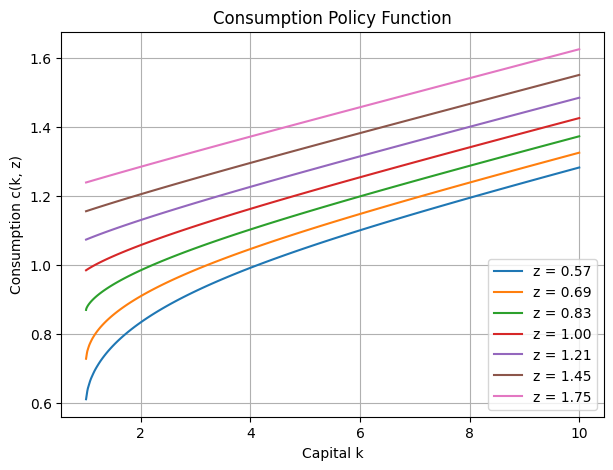

In [104]:
### arbitrary z grid

plt.figure(figsize=(7,5))

for iz, z in enumerate(n_grid):
    plt.plot(k_grid, c_old[:,iz], label=f'z = {z:.2f}')
   # plt.plot(k_grid_egm, c_analytical(params, k_grid_egm, z), label=f'Anal z={z:.2f}', linestyle='-')


plt.xlabel('Capital k')
plt.ylabel('Consumption c(k, z)')
plt.title('Consumption Policy Function')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def transition_matrix_vectorized(Pi, pol_idx, k_grid, z_grid):
    Na = len(k_grid)
    Nz = len(z_grid)

    a_idx = np.arange(Na).reshape(1, 1, Na, 1)
    pol = pol_idx.reshape(Na, Nz, 1, 1)

    a_indicator = (pol == a_idx).astype(float)
    Pi_re = Pi.reshape(1, Nz, 1, Nz)

    P = a_indicator * Pi_re
    return P.reshape(Na * Nz, Na * Nz)

def stationary_hugett_mini(Pi,pol_idx,k_grid,z_grid):

  k_num = len(k_grid)
  z_num = len(z_grid)

  ### compute the actual distribution for the asset supply
  transition = transition_matrix_vectorized(Pi,pol_idx,k_grid,z_grid)

  ## using eigen_vector method
  pi = stationary_distribution(transition.T)
  pi = pi.reshape(k_num,z_num)
  ## distribution of asset
  a_dist = pi.sum(axis=1)

  ### check distribution of asset supply
  if not np.isclose(a_dist.sum(), 1.0):
    ValueError("mass of probability not equal to 1 !!")
  mean_assets = np.dot(k_grid.ravel(), a_dist.ravel())

  return mean_assets


def Aiyagari_Eql(r,eql_params,a_max=20,n=2):                                ### to solve interest rate graphically
  """
  r :array of interest rates
  eql_params : dict of other parameters of the economy - not the best way to code - slower in general - good for readability
  return : list of asset supply for each interest rate in r
  """
  results = []
  k_grid, Pi, pi, n_grid = create_grid(params)                                                                                 ### need to write this
  for ir in r:
    ## model - demand side
    k_dd_mean = mpl(params,ir)
    ### labor dd
    H = np.dot(pi,n_grid)
    w = inv_mpl(H)
    ## model instance
    Baseline_Aiyagari_model = Baseline_Aiyagari(params, ir, w, k_grid, Pi, pi, n_grid)
    solution = Baseline_Aiyagari_model.EGM_AiyaG(params, ir, w, k_grid, Pi, pi, n_grid)
    k_ss_mean = stationary_aiyagari_mini(Pi,pol_idx,a,y)                                   ### need to write this
    results.append(k_ss_mean)

  return results

def Aiyagari_Eql_num(params,ir):                          ### to solve interest rate numerically

  k_grid, Pi, pi, n_grid = create_grid(params)
  ## model - demand side
  k_dd_mean = mpl(params,ir)
  ## labor supply
  H = np.dot(pi,n_grid)
  w = inv_mpl(H,k_dd_mean)
  ### instance model - supply side
  Baseline_Aiyagari_model = Baseline_Aiyagari(params, ir, w, k_grid, Pi, pi, n_grid)
  solution = Baseline_Aiyagari_model.EGM_AiyaG(params, ir, w, k_grid, Pi, pi, n_grid)
  k_ss_mean = stationary_aiyagari_mini(Pi,pol_idx,a,y)



  net_k_dd = k_dd_mean - k_ss_mean
  return net_k_dd



## Baseline Aiyagari from course

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, RegularGridInterpolator

class AiyagariEconomy:
    def __init__(self, β=params.beta, γ=params.gamma, α=params.alpha, δ=params.delta, ρ=params.rho, r=params.r, w=1.0,
                 σe=params.sigma, my=0.0, ny=params.nbn, na=params.nbk, dist_tol=1e-6, maxit=1000, lb=0.037):
        self.β, self.γ, self.α, self.δ, self.ρ = β, γ, α, δ, ρ
        self.r, self.w, self.σe, self.my = r, w, σe, my
        self.ny, self.ne, self.na = ny, ny, na
        self.dist_tol, self.maxit, self.lb = dist_tol, maxit, lb

        self.ub = 1.0/β - 1.0 - 0.0001
        self.σy = np.sqrt((σe**2) / (1 - ρ**2))
        self.amax = params.k_max

        # Grid construction (log-spaced density at bottom)
        a_temp = np.log(np.linspace(np.exp(1.0), na, na))
        self.agrid = (np.cumsum(a_temp) / np.sum(a_temp)) * self.amax

        # Rouwenhorst Method for ygrid and Transition Matrix
        p = (1.0 + ρ) / 2
        q = p
        ψ = self.σy * np.sqrt(ny - 1)
        self.ygrid = np.linspace(-ψ, ψ, ny)

        # Transition Matrix
        Π = np.array([[p, 1-p], [1-q, q]])
        for _ in range(ny - 2):
            n = Π.shape[0]
            new_Π = np.zeros((n + 1, n + 1))
            new_Π[:-1, :-1] += p * Π
            new_Π[:-1, 1:] += (1 - p) * Π
            new_Π[1:, :-1] += (1 - q) * Π
            new_Π[1:, 1:] += q * Π
            new_Π[1:-1, :] /= 2
            Π = new_Π
        self.Πy = Π

        # Invariant Distribution of shocks
        vals, vecs = np.linalg.eig(self.Πy.T)
        self.Πyinv = np.real(vecs[:, np.argmin(np.abs(vals - 1.0))])
        self.Πyinv /= np.sum(self.Πyinv)

        self.ϵgrid = np.exp(self.ygrid + self.my)
        print(self.ϵgrid)
        self.H = np.dot(self.ϵgrid, self.Πyinv)
        self.K = 0.0
        self.cpol_mat = np.zeros((self.na, self.ny))
        self.a_ast_mat = np.tile(self.agrid.reshape(-1, 1), (1, self.ny))

        # Finer grid for distribution
        a_finer_temp = np.log(np.linspace(np.exp(0.0), 3 * na, 3 * na))
        self.agrid_finer = (np.cumsum(a_finer_temp) / np.sum(a_finer_temp)) * self.amax

# --- Utility and Production Functions ---
def uprime(ay, c): return c**(-ay.γ)
def upinv(ay, vv): return vv**(-1.0 / ay.γ)
def mpk_fun(ay, K): return ay.α * K**(ay.α - 1.0) * ay.H**(1.0 - ay.α)
def mpl_fun(ay, K): return (1.0 - ay.α) * K**ay.α * ay.H**(-ay.α)
def inv_mpk(ay, rr): return ay.H * (ay.α / (rr + ay.δ))**(1.0 / (1.0 - ay.α))

# --- Core Solver Functions ---

def endogrid_bang(ay):
    R = 1.0 + ay.r
    b = ay.agrid[0]
    zgrid = ay.ϵgrid * ay.w

    # RHS of Euler Equation: Expectation over tomorrow's marginal utility
    # (ay.β * R * Πy * u'(c_next)).T in Julia logic
    B = (ay.β * R * ay.Πy @ uprime(ay, ay.cpol_mat.T)).T
    ctil = upinv(ay, B)

    # Endogenous Grid: a_today = (a_tomorrow + c_today - income) / R
    a_ast = (ay.agrid[:, None] + ctil - zgrid[None, :]) / R

    cpol_out = np.zeros((ay.na, ay.ny))
    for i_z in range(ay.ny):
        # Linear Interpolation/Extrapolation
        interp = interp1d(a_ast[:, i_z], ctil[:, i_z], fill_value="extrapolate", bounds_error=False)
        c_vals = interp(ay.agrid)

        # Constrained case
        constrained = ay.agrid <= a_ast[0, i_z]
        c_vals[constrained] = R * ay.agrid[constrained] + b + zgrid[i_z]
        cpol_out[:, i_z] = c_vals

    ay.cpol_mat = cpol_out
    ay.a_ast_mat = a_ast


    return cpol_out, a_ast, zgrid

def compute_invariant_pwlinear(ay, Λ_invariant):
    Λnm1_mat = Λ_invariant.copy()

    # Interpolator for a_ast (assets tomorrow as function of assets today)
    # We use RegularGridInterpolator for 2D lookups
    a_ast_itp = RegularGridInterpolator((ay.agrid, ay.ygrid), ay.a_ast_mat,
                                        method='linear', bounds_error=False, fill_value=None)

    for iter_dist in range(2000):
        Λn_mat = np.zeros((len(ay.agrid_finer), ay.ny))

        for i_y_next in range(ay.ny):
            for i_a, a_val in enumerate(ay.agrid_finer):
                vec_temp = 0.0
                for i_y_today in range(ay.ny):
                    # Where did this person come from?
                    a_today = np.clip(a_ast_itp((a_val, ay.ygrid[i_y_today])), ay.agrid[0], ay.agrid[-1])

                    # Locate on finer grid for distribution update
                    idx = np.searchsorted(ay.agrid_finer, a_today) - 1
                    idx = max(0, min(idx, len(ay.agrid_finer) - 2))

                    # Piecewise linear weight
                    dist_gap = ay.agrid_finer[idx+1] - ay.agrid_finer[idx]
                    weight = (a_today - ay.agrid_finer[idx]) / dist_gap

                    Λ_val = Λnm1_mat[idx, i_y_today] + weight * (Λnm1_mat[idx+1, i_y_today] - Λnm1_mat[idx, i_y_today])
                    vec_temp += ay.Πy[i_y_today, i_y_next] * Λ_val

                Λn_mat[i_a, i_y_next] = vec_temp

        dist = np.max(np.abs(Λn_mat - Λnm1_mat))
        Λnm1_mat = Λn_mat.copy()
        if dist < 1e-4: break

    return Λnm1_mat

def compute_supply(ay, rr):
    r0_fixed = -0.1 * ay.δ + 0.9 * (1.0/ay.β - 1.0)
    KK0 = inv_mpk(ay, r0_fixed)
    ww0 = mpl_fun(ay, KK0)
    zgrid = ay.ϵgrid * ww0

    # Initialize Consumption Policy
    for i_z in range(ay.ny):
        ay.cpol_mat[:, i_z] = (1.0 + r0_fixed) * ay.agrid + ww0 * zgrid[i_z] - 0.05

    ay.r = params.r
    ay.K = inv_mpk(ay, ay.r)
    #ay.w = mpl_fun(ay, ay.K)
    ay.w = 1

    # Policy Iteration
    for _ in range(ay.maxit):
        old_pol = ay.cpol_mat.copy()
        cpol_out, a_ast, zgrid_1  = endogrid_bang(ay)
        if np.max(np.abs(old_pol - ay.cpol_mat)) < ay.dist_tol: break

    # # Initialize Distribution
    # Λ_inv = np.zeros((len(ay.agrid_finer), ay.ny))
    # for i_y in range(ay.ny):
    #     Λ_inv[:, i_y] = (ay.agrid_finer - ay.agrid[0]) / (ay.agrid[-1] - ay.agrid[0]) * ay.Πyinv[i_y]

    # Λ_final = compute_invariant_pwlinear(ay, Λ_inv)

    # # Aggregate Capital Supply via Integration
    # A_supply = 0.0
    # for i_y in range(ay.ny):
    #     # trapezoidal sum of a * f(a)
    #     da = np.diff(ay.agrid_finer)
    #     mid_a = (ay.agrid_finer[1:] + ay.agrid_finer[:-1]) / 2
    #     dΛ = np.diff(Λ_final[:, i_y])
    #     A_supply += np.sum(dΛ * mid_a) + Λ_final[0, i_y] * ay.agrid_finer[0]

    return cpol_out, a_ast, zgrid_1

In [82]:
start = time()
ay = AiyagariEconomy()
cpol_out, a_ast, z_vals = compute_supply(ay, 0.2)
end = time()
print("Time of execution: "+str(end-start))

[0.57009544 0.68754065 0.82918071 1.         1.20600973 1.45445946
 1.75409225]
Time of execution: 0.29544496536254883


In [83]:
z_vals

array([0.57009544, 0.68754065, 0.82918071, 1.        , 1.20600973,
       1.45445946, 1.75409225])

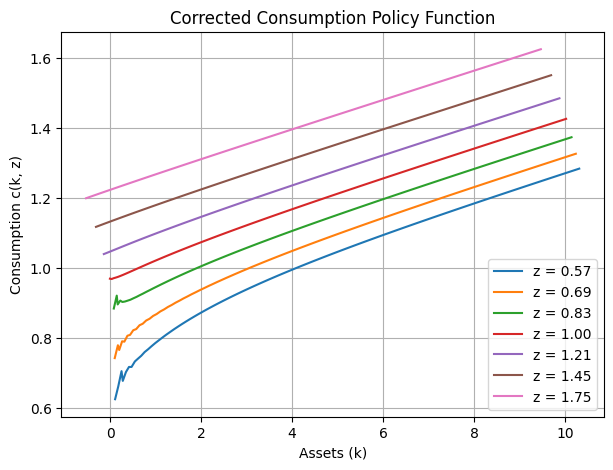

In [84]:
plt.figure(figsize=(7,5))
for iz in range(ay.ny):
    # Use the shock value for the label
    current_z = z_vals[iz]
    # Plot the policy result (c) against the actual asset grid (a)
    plt.plot(a_ast[:, iz], cpol_out[:, iz], label=f'z = {current_z:.2f}')

plt.xlabel('Assets (k)')
plt.ylabel('Consumption c(k, z)')
plt.title('Corrected Consumption Policy Function')
plt.legend()
plt.grid(True)
plt.show()

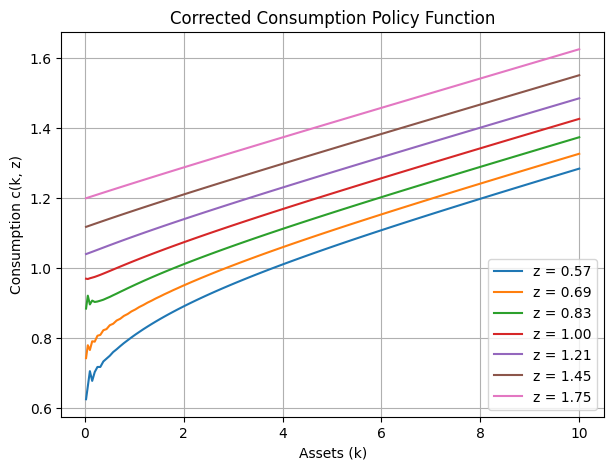

In [85]:
plt.figure(figsize=(7,5))
for iz in range(ay.ny):
    # Use the shock value for the label
    current_z = z_vals[iz]
    # Plot the policy result (c) against the actual asset grid (a)
    plt.plot(ay.agrid, cpol_out[:, iz], label=f'z = {current_z:.2f}')

plt.xlabel('Assets (k)')
plt.ylabel('Consumption c(k, z)')
plt.title('Corrected Consumption Policy Function')
plt.legend()
plt.grid(True)
plt.show()

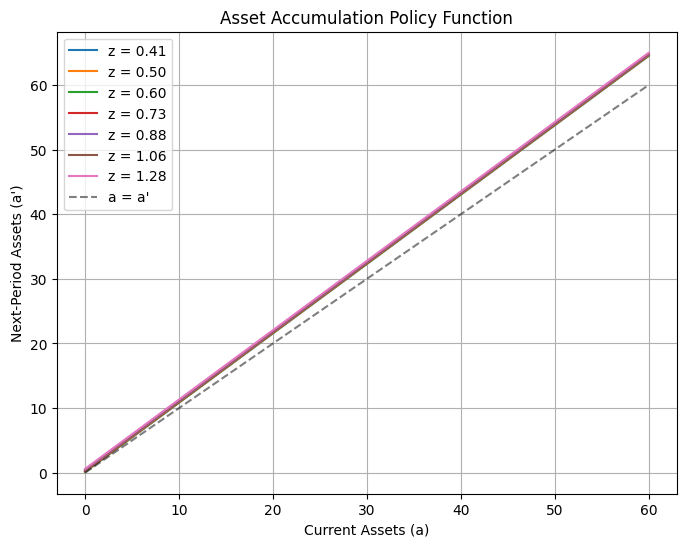

In [158]:
# Calculate next-period assets using the budget constraint
# a_final size: (na, ny)
R = 1 + ay.r
z_earnings = ay.w * ay.ϵgrid
a_final = R * ay.agrid[:, None] + z_earnings[None, :] - cpol_out

# Plotting
plt.figure(figsize=(8, 6))
for i in range(ay.ny):
    # Plot current assets (ay.agrid) vs next-period assets (a_final)
    plt.plot(ay.agrid, a_final[:, i], label=f'z = {z_earnings[i]:.2f}')

# Add a 45-degree line to show asset growth vs decumulation
plt.plot(ay.agrid, ay.agrid, color='black', linestyle='--', alpha=0.5, label='a = a\'')

plt.xlabel('Current Assets (a)')
plt.ylabel('Next-Period Assets (a\')')
plt.title('Asset Accumulation Policy Function')
plt.legend()
plt.grid(True)
plt.show()

## Aiyagari with job search

## Aiyagari with labor supply

## Aiyagari with aggregate shocks (business cycle)

stationary rational expectations equilibrium-  aggregate quantities and prices are constant over time


pick a proposed quantity
 for aggregate capital

determine corresponding prices, with interest rate
 determined by (68.1) and a wage rate
 as given in (68.2)

determine the common optimal savings policy of the households given these prices

compute aggregate capital as the mean of steady state capital given this savings policy

# Bewley model
( CCarroll)

## Appendix

In [ ]:

def create_grid(params):
  """
  params : namedtuple with all the parameters
  creates the capital and idiosyncratic labor grid
  returns both grid and transistion and stationary distribution for idiosyncratic labor

  """

  ## create the state space for the problem
  ## non linear grid
  a_uniform = np.linspace(0, 1, params.nbk)
  a_transformed = a_uniform**2
  k_grid = params.k_min + (params.k_max - params.k_min) * a_transformed## continous state/ discrete state

  if params.rou == 1:
      Pi, pi, n_grid = discretize_state(params)
  else:
      Pi, n_grid = params.Pi, params.y
      pi = stationary_distribution_stable(Pi)
  return k_grid, Pi, pi, n_grid


def euler_inv_RW(params, n_grid, k_grid, interp_c, Pi, idx_n , r):

  """
  params : namedtuple with all the parameters
  k_grid : grid for capital used in interpolant - np.array
  c_policy : consumption policy function used in interpolant - np.array
  idx_n : index of last observed value for n - float
  n_grid : grid for n - np.array
  k_prime : next period capital since egm - float

  """

  # Vectorize the shocks
  # We evaluate all shocks for this specific k_prime

  np_mesh, kp_mesh = np.meshgrid(n_grid, k_grid, indexing='ij')
  pts = np.column_stack((np_mesh.ravel(), kp_mesh.ravel()))

  # Interpolate next-period consumption for all state variables at once
  cp = interp_c(pts).reshape(len(n_grid), len(k_grid))

  # mu_c and fprime should be vectorized to handle the 'cp' and 'z_primes' arrays
  mu_c_arr = mu_c(params, cp) * (1+r)
  prob_last = Pi[idx_n,:]
  expec = np.sum(prob_last [:, None] *mu_c_arr, axis = 0 )

  return mu_c_inv(params, params.beta * expec )


def solver_egm(params, r, w, k_grid, Pi, pi, n_grid, tol = 1e-6, error = 1, iter = 0, max_iter = 1000):

  ## making it like huggett/ bewley
  y_grid = w*n_grid

  ## starting array for c
  c_old =  0.8*(y_grid[:, None] +  (1+r)*k_grid[None, :])

  ## iteration
  for iter in range(max_iter):

    c_new = np.empty_like(c_old)

    for idx_y, y in enumerate(y_grid):
      k_1 = np.empty_like(k_grid)                ### present period capital - endogenous
      c_1 = np.empty_like(k_grid)               ### present period consumption - endogeneous

      ## Create a 2D interpolator object for the current c_policy


      interp_c = RegularGridInterpolator((y_grid, k_grid), c_old,
                                          bounds_error=False, fill_value=None)


      ## calculate the c - from euler equation
      c_1 = euler_inv_RW(params, y_grid, k_grid, interp_c, Pi, idx_y, r)
      c_1 = np.maximum(c_1, 1e-12)
      ## calculate the k - from budget equation
      #print(z)
      k_1 = (k_grid + c_1 - y)/(1+r)
      ## checking for borrowing constraint
      # k_1 = np.maximum(k_1, params.k_min)

      idx = np.argsort(k_1)
      k_1 = k_1[idx]
      c_1 = c_1[idx]

      c_new[idx_y, :] = np.interp(k_grid, k_1, c_1,left=c_1[0], right=c_1[-1])
      c_new[idx_y, :] = np.maximum(c_new[idx_y, :], 1e-12)
      ## near borrowing constraint
      mask = k_grid < k_1[0]
      c_new[idx_y, mask] = y +  (1+r)*k_grid[mask] - params.k_min

    error = np.max(np.abs(c_new - c_old))
    c_old[:] = c_new

    if error < tol:
      print(f"Converged in {iter} iterations")
      break
  return c_old, k_grid, y_grid


class Baseline_Aiyagari:

    def __init__(self,params,r,w):
        """
        class creates a solver for an aiyagari economy using EGM

        """
        self.params = params
        self.r = r
        self.w = w


    def EGM_AiyaG(self, params, r, w, tol = 10**-6, max_iter = 1000):

      k_grid, Pi, pi, n_grid = create_grid(params)
      ## return the policy functions through njit class
      return solver_egm(params, r, w, k_grid, Pi, pi, n_grid, tol = 1e-6, error = 1, iter = 0, max_iter = 1000)

